# Exploratory Data Analysis — Screen Time & Mental Wellness

**Dataset** : ScreenTime vs MentalWellness (400 personnes, 15 features)  
**Target** : `mental_wellness_index_0_100` — score de bien-être mental (0 = très mauvais, 100 = excellent)  
**Problème** : Régression — prédire un score continu

**Plan de l'EDA** :
1. Aperçu général des données
2. Analyse de la target
3. Analyse de chaque feature (distribution + outliers + décision)
4. Corrélations avec la target
5. Relations entre features
6. Analyse des outliers globale
7. Analyse de chaque modèle

## 1. Aperçu général

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/ScreenTime vs MentalWellness.csv").drop(columns=["user_id", "Unnamed: 15"], errors="ignore")

TARGET = "mental_wellness_index_0_100"
NUM_COLS = ["age", "screen_time_hours", "work_screen_hours", "leisure_screen_hours",
            "sleep_hours", "sleep_quality_1_5", "stress_level_0_10",
            "productivity_0_100", "exercise_minutes_per_week", "social_hours_per_week"]
CAT_COLS = ["gender", "occupation", "work_mode"]

print(f"Dimensions       : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"\nTarget '{TARGET}' : min={df[TARGET].min()} | max={df[TARGET].max()} | moyenne={df[TARGET].mean():.1f}")
df.head()

Dimensions       : 400 lignes × 14 colonnes
Valeurs manquantes : 0

Target 'mental_wellness_index_0_100' : min=0.0 | max=97.0 | moyenne=20.3


,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


In [2]:
df.describe().round(2)

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,29.78,9.02,2.18,6.84,7.01,1.40,8.15,54.31,109.81,7.90,20.33
std,7.47,2.49,1.93,2.22,0.85,0.65,2.09,15.02,70.01,4.91,20.38
min,16.00,1.00,0.11,0.89,4.64,1.00,0.00,20.60,0.00,0.00,0.00
25%,24.00,7.37,0.70,5.46,6.40,1.00,6.90,43.60,58.00,4.57,3.68
50%,30.00,9.09,1.46,6.70,7.03,1.00,8.80,51.75,103.00,7.75,14.80
75%,35.00,10.50,3.01,8.42,7.64,2.00,10.00,63.00,157.00,11.02,30.65
max,60.00,19.17,12.04,13.35,9.74,4.00,10.00,100.00,372.00,23.90,97.00


## 2. Analyse de la target : `mental_wellness_index_0_100`

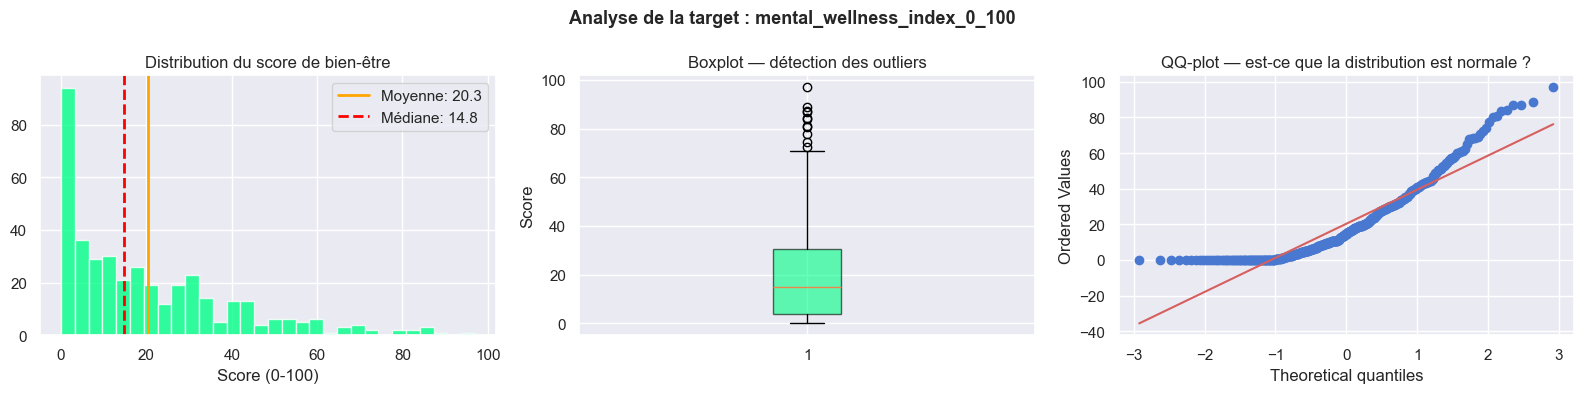

Skewness (asymétrie) : 1.229  → asymétrique ⚠️
Kurtosis (aplatissement) : 1.186

→ Score moyen : 20.3 / 100


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme
axes[0].hist(df[TARGET], bins=30, color="#00ff87", edgecolor="white", alpha=0.8)
axes[0].axvline(df[TARGET].mean(), color="orange", linewidth=2, label=f"Moyenne: {df[TARGET].mean():.1f}")
axes[0].axvline(df[TARGET].median(), color="red", linewidth=2, linestyle="--", label=f"Médiane: {df[TARGET].median():.1f}")
axes[0].set_title("Distribution du score de bien-être")
axes[0].set_xlabel("Score (0-100)")
axes[0].legend()

# Boxplot
axes[1].boxplot(df[TARGET], patch_artist=True, boxprops=dict(facecolor="#00ff87", alpha=0.6))
axes[1].set_title("Boxplot — détection des outliers")
axes[1].set_ylabel("Score")

# QQ-plot (normalité)
stats.probplot(df[TARGET], dist="norm", plot=axes[2])
axes[2].set_title("QQ-plot — est-ce que la distribution est normale ?")

plt.suptitle("Analyse de la target : mental_wellness_index_0_100", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

skew = df[TARGET].skew()
kurt = df[TARGET].kurtosis()
print(f"Skewness (asymétrie) : {skew:.3f}  → {'distribution symétrique ✅' if abs(skew) < 0.5 else 'asymétrique ⚠️'}")
print(f"Kurtosis (aplatissement) : {kurt:.3f}")
print(f"\n→ Score moyen : {df[TARGET].mean():.1f} / 100")

## 3. Analyse de chaque feature — Distribution + Outliers + Décision

Pour chaque variable numérique :
- **Histogramme** : forme de la distribution
- **Boxplot** : détection des outliers (points hors des moustaches)
- **Décision** : garder ou supprimer les outliers, avec justification

/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


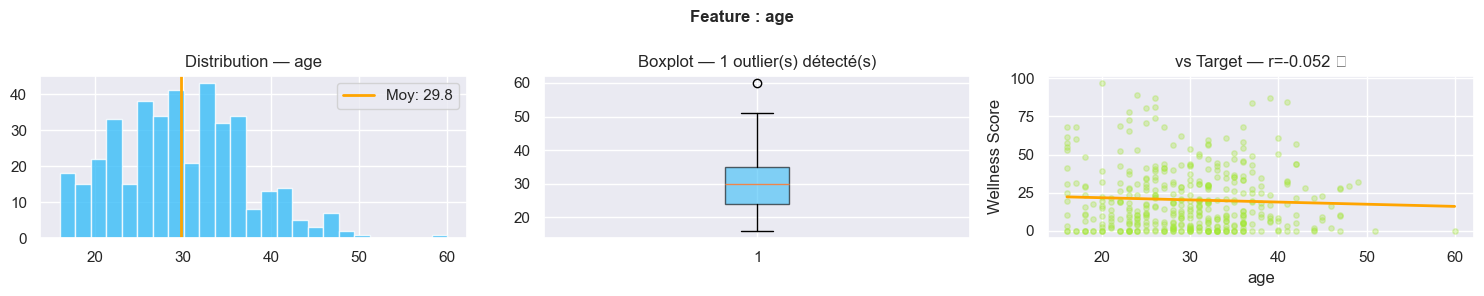

  Outliers : 1 (0.2%)
  Bornes IQR : [7.50, 51.50]
  ✏️  Décision : Garder — les âges extrêmes (très jeunes ou très vieux) sont des profils réels.



/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


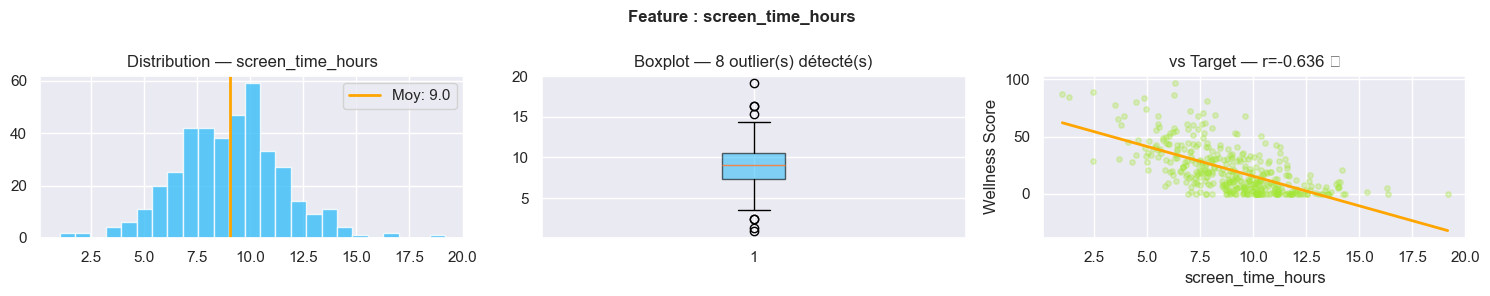

  Outliers : 8 (2.0%)
  Bornes IQR : [2.69, 15.18]
  ✏️  Décision : Garder — des personnes passent vraiment 15h+/jour sur écran (télétravail + loisirs).



/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


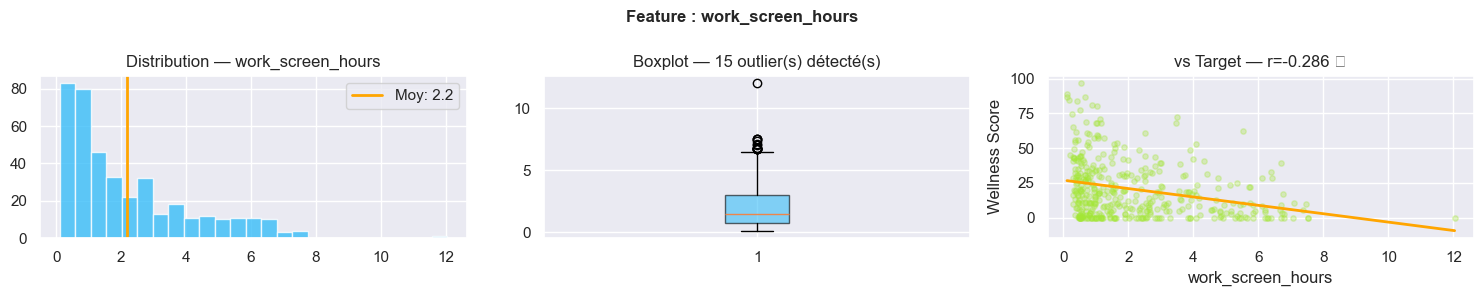

  Outliers : 15 (3.8%)
  Bornes IQR : [-2.78, 6.49]
  ✏️  Décision : Garder — certains métiers nécessitent de longues heures devant ordinateur.



/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


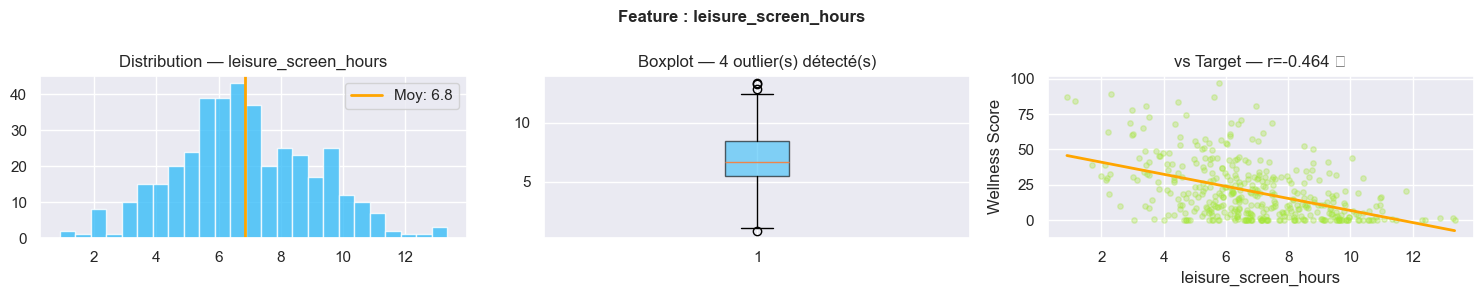

  Outliers : 4 (1.0%)
  Bornes IQR : [1.02, 12.85]
  ✏️  Décision : Garder — usage intensif du téléphone/streaming est une réalité.



/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


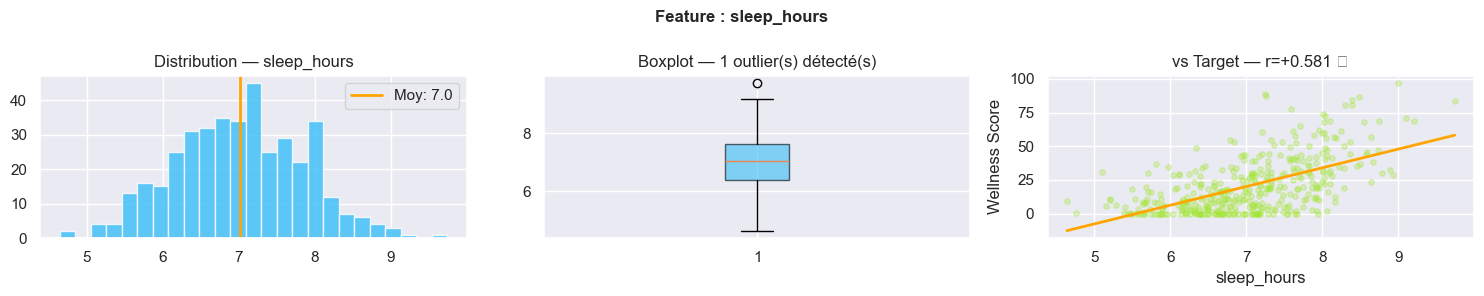

  Outliers : 1 (0.2%)
  Bornes IQR : [4.53, 9.50]
  ✏️  Décision : Garder — dormir 3h ou 10h est physiologiquement possible et informatif.



/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


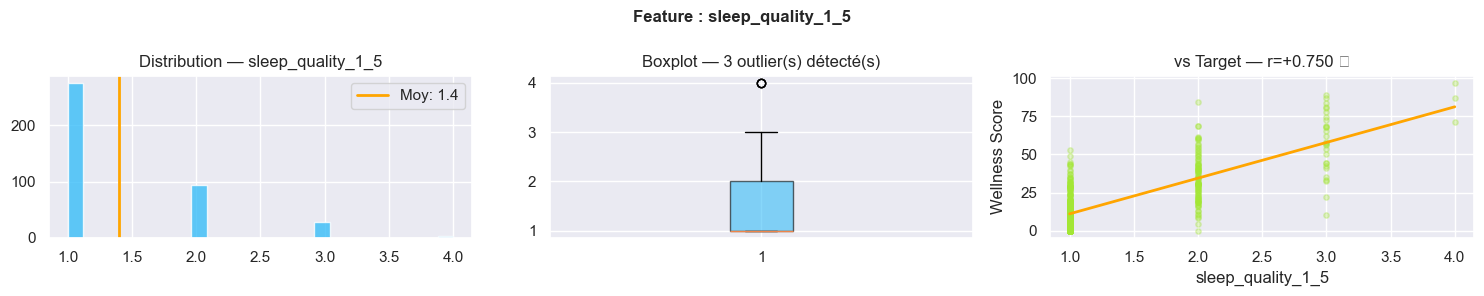

  Outliers : 3 (0.8%)
  Bornes IQR : [-0.50, 3.50]
  ✏️  Décision : Garder — score discret 1-5, pas d'outlier possible.



/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


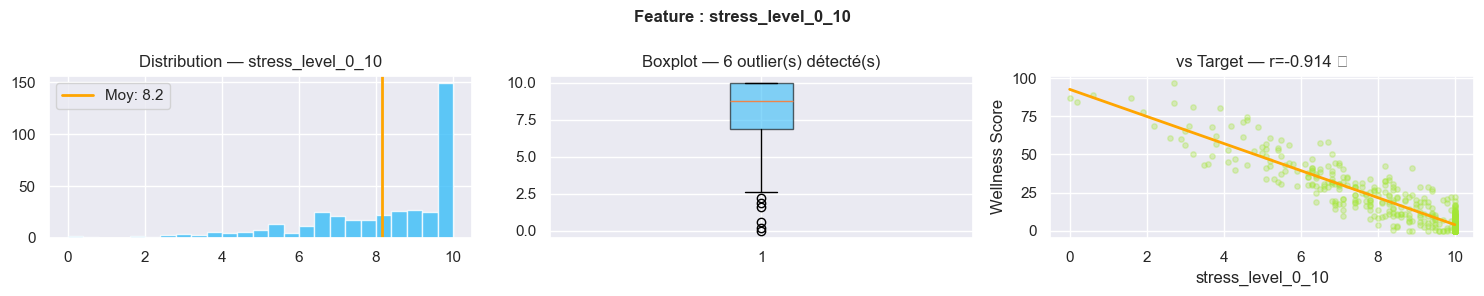

  Outliers : 6 (1.5%)
  Bornes IQR : [2.25, 14.65]
  ✏️  Décision : Garder — score discret 0-10, valeurs extrêmes représentent des cas réels.



/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


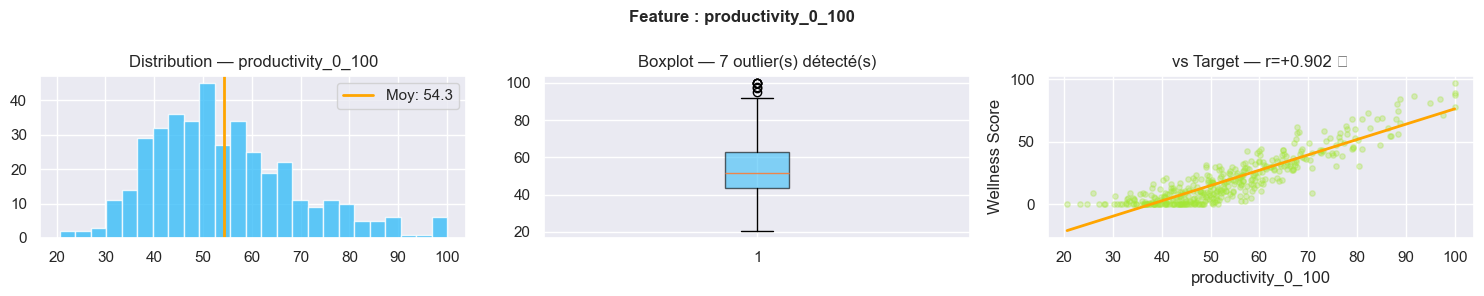

  Outliers : 7 (1.8%)
  Bornes IQR : [14.50, 92.10]
  ✏️  Décision : Garder — score continu 0-100, les extrêmes sont des cas réels.



/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


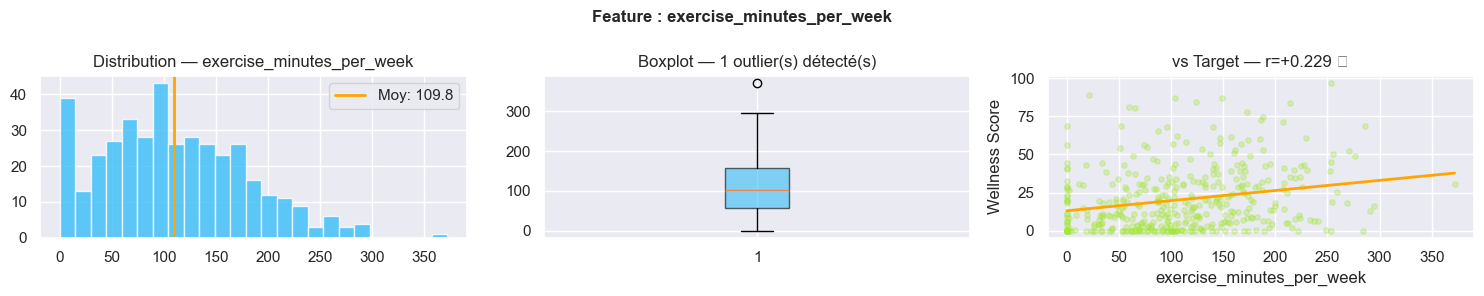

/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/4060239260.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()


  Outliers : 1 (0.2%)
  Bornes IQR : [-90.50, 305.50]
  ✏️  Décision : Garder — 0 min (sédentaire total) et 400+ min (sportif intensif) sont réels.



/Users/sachabenichou/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


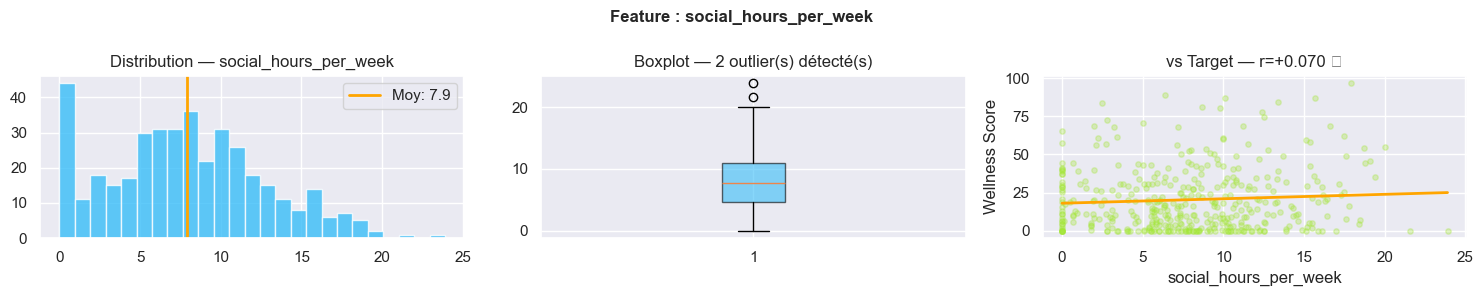

  Outliers : 2 (0.5%)
  Bornes IQR : [-5.10, 20.70]
  ✏️  Décision : Garder — isolement social (0h) ou très sociable (15h+) sont des réalités.


=== RÉCAPITULATIF ===


,Feature,Moyenne,Std,Outliers,% outliers,r avec target,Significatif,Décision
0,age,29.78,7.47,1,0.2,-0.052,❌,Garder
1,screen_time_hours,9.02,2.49,8,2.0,-0.636,✅,Garder
2,work_screen_hours,2.18,1.93,15,3.8,-0.286,✅,Garder
3,leisure_screen_hours,6.84,2.22,4,1.0,-0.464,✅,Garder
4,sleep_hours,7.01,0.85,1,0.2,0.581,✅,Garder
5,sleep_quality_1_5,1.40,0.65,3,0.8,0.750,✅,Garder
6,stress_level_0_10,8.15,2.09,6,1.5,-0.914,✅,Garder
7,productivity_0_100,54.31,15.02,7,1.8,0.902,✅,Garder
8,exercise_minutes_per_week,109.81,70.01,1,0.2,0.229,✅,Garder
9,social_hours_per_week,7.90,4.91,2,0.5,0.070,❌,Garder


In [4]:
DECISIONS = {
    "age":                           "Garder — les âges extrêmes (très jeunes ou très vieux) sont des profils réels.",
    "screen_time_hours":             "Garder — des personnes passent vraiment 15h+/jour sur écran (télétravail + loisirs).",
    "work_screen_hours":             "Garder — certains métiers nécessitent de longues heures devant ordinateur.",
    "leisure_screen_hours":          "Garder — usage intensif du téléphone/streaming est une réalité.",
    "sleep_hours":                   "Garder — dormir 3h ou 10h est physiologiquement possible et informatif.",
    "sleep_quality_1_5":             "Garder — score discret 1-5, pas d'outlier possible.",
    "stress_level_0_10":             "Garder — score discret 0-10, valeurs extrêmes représentent des cas réels.",
    "productivity_0_100":            "Garder — score continu 0-100, les extrêmes sont des cas réels.",
    "exercise_minutes_per_week":     "Garder — 0 min (sédentaire total) et 400+ min (sportif intensif) sont réels.",
    "social_hours_per_week":         "Garder — isolement social (0h) ou très sociable (15h+) sont des réalités.",
}

summary = []

for col in NUM_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    fig, axes = plt.subplots(1, 3, figsize=(15, 3))

    axes[0].hist(df[col], bins=25, color="#38bdf8", edgecolor="white", alpha=0.8)
    axes[0].set_title(f"Distribution — {col}")
    axes[0].axvline(df[col].mean(), color="orange", label=f"Moy: {df[col].mean():.1f}", linewidth=2)
    axes[0].legend()

    axes[1].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor="#38bdf8", alpha=0.6),
                    flierprops=dict(marker="o", color="red", markersize=6))
    axes[1].set_title(f"Boxplot — {n_out} outlier(s) détecté(s)")

    axes[2].scatter(df[col], df[TARGET], alpha=0.3, color="#a3e635", s=15)
    m, b = np.polyfit(df[col], df[TARGET], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[2].plot(x_line, m*x_line + b, color="orange", linewidth=2)
    r, p = stats.pearsonr(df[col], df[TARGET])
    axes[2].set_title(f"vs Target — r={r:+.3f} {'✅' if p < 0.05 else '❌'}")
    axes[2].set_xlabel(col)
    axes[2].set_ylabel("Wellness Score")

    plt.suptitle(f"Feature : {col}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"  Outliers : {n_out} ({n_out/len(df)*100:.1f}%)")
    print(f"  Bornes IQR : [{lower:.2f}, {upper:.2f}]")
    print(f"  ✏️  Décision : {DECISIONS[col]}\n")

    summary.append({"Feature": col, "Moyenne": round(df[col].mean(),2),
                    "Std": round(df[col].std(),2), "Outliers": n_out,
                    "% outliers": round(n_out/len(df)*100,1),
                    "r avec target": round(r,3), "Significatif": "✅" if p < 0.05 else "❌",
                    "Décision": "Garder"})

print("\n=== RÉCAPITULATIF ===")
pd.DataFrame(summary)

## 4. Corrélations avec la target — Heatmap complète

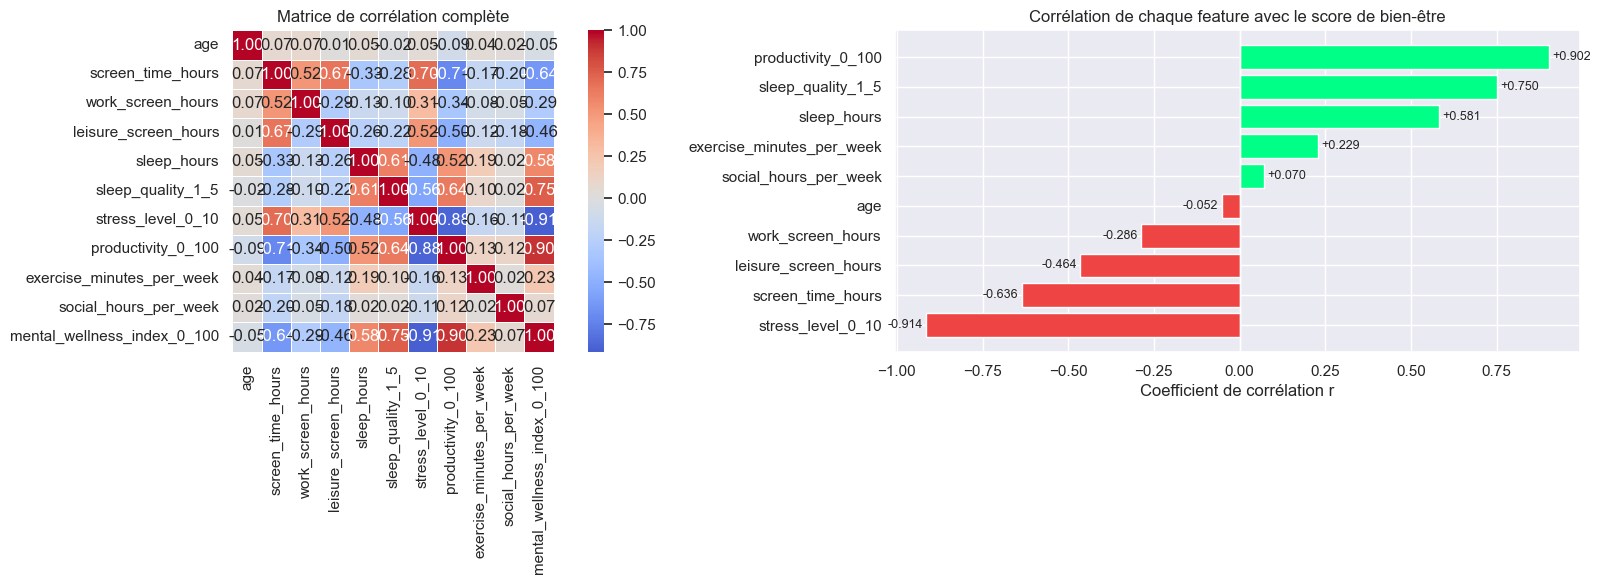

Interprétation :
  → Rouge  = corrélation négative (plus la valeur est haute, moins bonne est la santé mentale)
  → Vert   = corrélation positive (plus la valeur est haute, meilleure est la santé mentale)

  stress_level_0_10                   r=-0.914  → ↑ dégrade la santé mentale
  productivity_0_100                  r=+0.902  → ↑ améliore la santé mentale
  sleep_quality_1_5                   r=+0.750  → ↑ améliore la santé mentale
  screen_time_hours                   r=-0.636  → ↑ dégrade la santé mentale
  sleep_hours                         r=+0.581  → ↑ améliore la santé mentale
  leisure_screen_hours                r=-0.464  → ↑ dégrade la santé mentale
  work_screen_hours                   r=-0.286  → ↑ dégrade la santé mentale
  exercise_minutes_per_week           r=+0.229  → ↑ améliore la santé mentale
  social_hours_per_week               r=+0.070  → ↑ améliore la santé mentale
  age                                 r=-0.052  → ↑ dégrade la santé mentale


In [5]:
corr = df[NUM_COLS + [TARGET]].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap complète
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title("Matrice de corrélation complète", fontsize=12)

# Corrélations avec la target uniquement
target_corr = corr[TARGET].drop(TARGET).sort_values()
colors = ["#ef4444" if v < 0 else "#00ff87" for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].axvline(0, color="white", linewidth=1)
axes[1].set_title("Corrélation de chaque feature avec le score de bien-être", fontsize=12)
axes[1].set_xlabel("Coefficient de corrélation r")
for i, v in enumerate(target_corr.values):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i, f"{v:+.3f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

print("Interprétation :")
print("  → Rouge  = corrélation négative (plus la valeur est haute, moins bonne est la santé mentale)")
print("  → Vert   = corrélation positive (plus la valeur est haute, meilleure est la santé mentale)")
print()
for feat, r in target_corr.sort_values(key=abs, ascending=False).items():
    direction = "↑ améliore" if r > 0 else "↑ dégrade"
    print(f"  {feat:35s} r={r:+.3f}  → {direction} la santé mentale")

## 5. Variables catégorielles — Genre, Occupation, Mode de travail

/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/1684071975.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(means.index, rotation=15, ha="right")
/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/1684071975.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(means.index, rotation=15, ha="right")
/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/1684071975.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(means.index, rotation=15, ha="right")
/var/folders/27/3htxnyvn3cdby_tcz3yp99g00000gn/T/ipykernel_34204/1684071975.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var

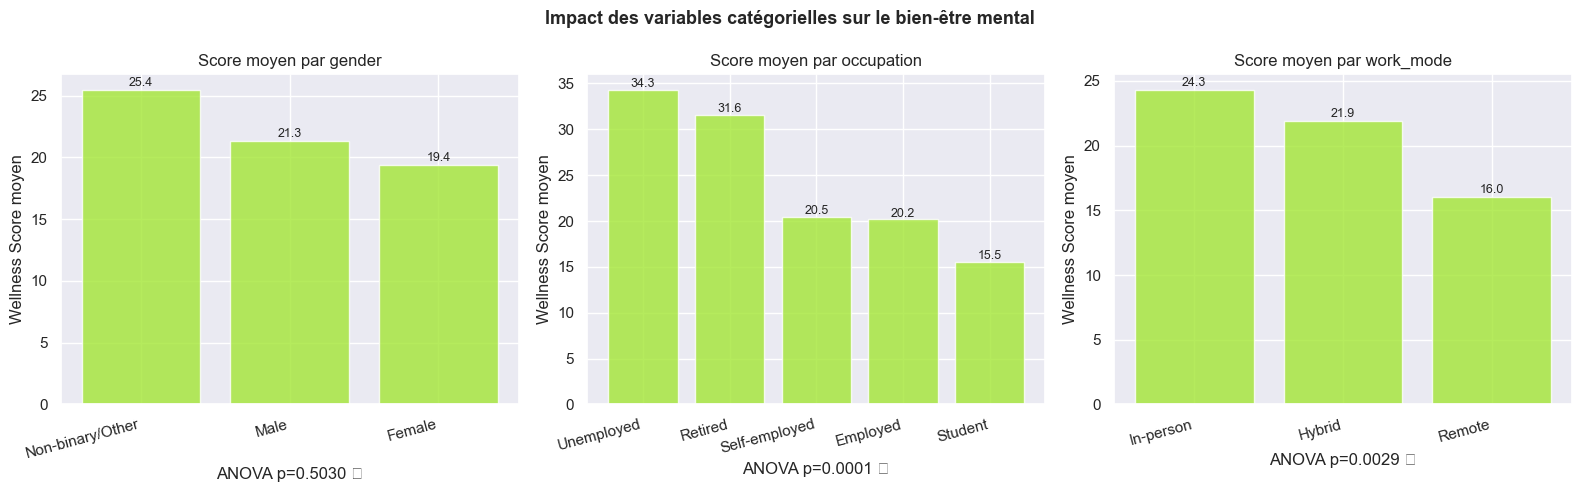

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(CAT_COLS):
    means = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    axes[i].bar(means.index, means.values, color="#a3e635", alpha=0.8)
    axes[i].set_title(f"Score moyen par {col}")
    axes[i].set_ylabel("Wellness Score moyen")
    axes[i].set_xticklabels(means.index, rotation=15, ha="right")
    for j, v in enumerate(means.values):
        axes[i].text(j, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

    # Test ANOVA
    groups = [df[df[col] == cat][TARGET].values for cat in df[col].unique()]
    f, p = stats.f_oneway(*groups)
    axes[i].set_xlabel(f"ANOVA p={p:.4f} {'✅' if p < 0.05 else '❌'}")

plt.suptitle("Impact des variables catégorielles sur le bien-être mental", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Santé mentale en fonction du temps d'écran — le graphique central du projet

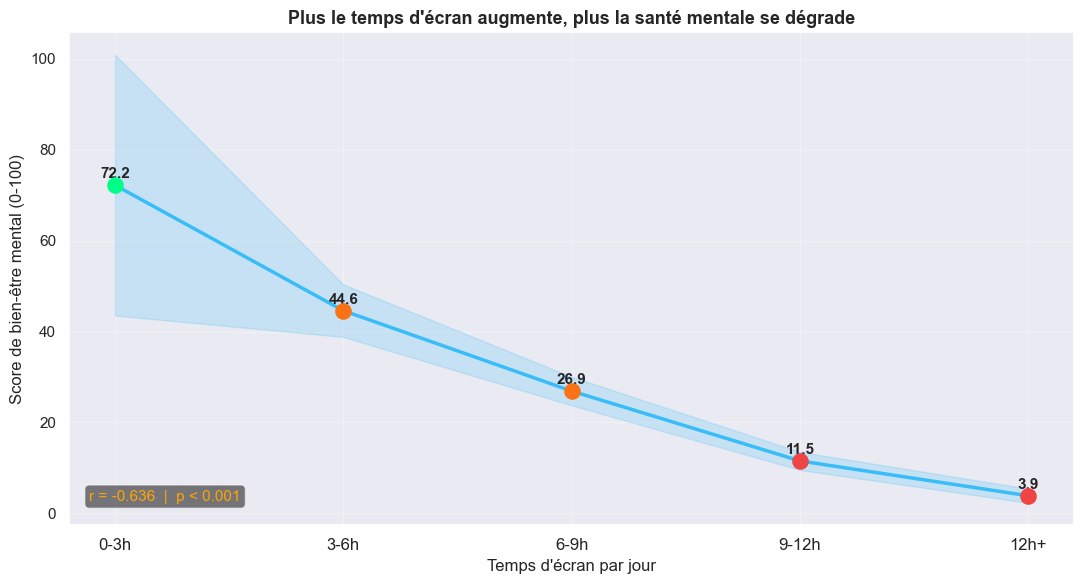

Corrélation r = -0.636 → lien négatif fort : plus d'écran = moins bonne santé mentale ✅


In [7]:
df["screen_bin"] = pd.cut(df["screen_time_hours"], bins=[0,3,6,9,12,25],
                          labels=["0-3h","3-6h","6-9h","9-12h","12h+"])
avg = df.groupby("screen_bin", observed=True)[TARGET].agg(["mean","sem"]).reset_index()
avg["ci"] = avg["sem"] * 1.96

fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(range(len(avg)), avg["mean"] - avg["ci"], avg["mean"] + avg["ci"],
                alpha=0.2, color="#38bdf8")
ax.plot(range(len(avg)), avg["mean"], color="#38bdf8", linewidth=2.5,
        marker="o", markersize=9, label="Score moyen ± IC 95%")

# Couleur des points selon le score
for i, row in avg.iterrows():
    color = "#00ff87" if row["mean"] > 50 else "#f97316" if row["mean"] > 25 else "#ef4444"
    ax.scatter(i, row["mean"], color=color, s=120, zorder=5)
    ax.text(i, row["mean"] + 1.5, f"{row['mean']:.1f}", ha="center", fontsize=11, fontweight="bold")

ax.set_xticks(range(len(avg)))
ax.set_xticklabels(avg["screen_bin"], fontsize=12)
ax.set_xlabel("Temps d'écran par jour", fontsize=12)
ax.set_ylabel("Score de bien-être mental (0-100)", fontsize=12)
ax.set_title("Plus le temps d'écran augmente, plus la santé mentale se dégrade",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)

r, p = stats.pearsonr(df["screen_time_hours"], df[TARGET])
ax.text(0.02, 0.05, f"r = {r:.3f}  |  p < 0.001", transform=ax.transAxes,
        fontsize=11, color="orange", bbox=dict(boxstyle="round", facecolor="black", alpha=0.5))

plt.tight_layout()
plt.show()
df.drop(columns=["screen_bin"], inplace=True)

print(f"Corrélation r = {r:.3f} → lien négatif fort : plus d'écran = moins bonne santé mentale ✅")

## 7. Analyse de chaque modèle — Performances & Erreurs

In [8]:
import joblib
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from config import MODELS_DIR
from data import load_dataset_split

X_train, X_test, y_train, y_test = load_dataset_split()

MODEL_NAMES = {
    "linear_reg":        "Linear Regression",
    "random_forest":     "Random Forest",
    "gradient_boosting": "Gradient Boosting",
    "knn":               "KNN",
    "svr":               "SVR",
}

results = {}
for key, name in MODEL_NAMES.items():
    m = joblib.load(MODELS_DIR / f"{key}.joblib")
    y_pred = m.predict(X_test)
    results[name] = {
        "y_pred": y_pred,
        "R²":   round(r2_score(y_test, y_pred), 4),
        "MAE":  round(mean_absolute_error(y_test, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "résidus": y_test - y_pred,
    }

# Tableau récapitulatif
df_res = pd.DataFrame({n: {k: v for k, v in d.items() if k not in ["y_pred","résidus"]}
                        for n, d in results.items()}).T
df_res = df_res.sort_values("R²", ascending=False)
print("=== PERFORMANCES DES MODÈLES ===")
print(df_res.to_string())
df_res

=== PERFORMANCES DES MODÈLES ===
                       R²   MAE  RMSE
Linear Regression  0.9335  4.01  5.13
Gradient Boosting  0.8987  5.02  6.33
Random Forest      0.8930  5.18  6.51
SVR                0.8638  5.79  7.34
KNN                0.8241  6.38  8.34


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying

,R²,MAE,RMSE
Linear Regression,0.9335,4.01,5.13
Gradient Boosting,0.8987,5.02,6.33
Random Forest,0.8930,5.18,6.51
SVR,0.8638,5.79,7.34
KNN,0.8241,6.38,8.34


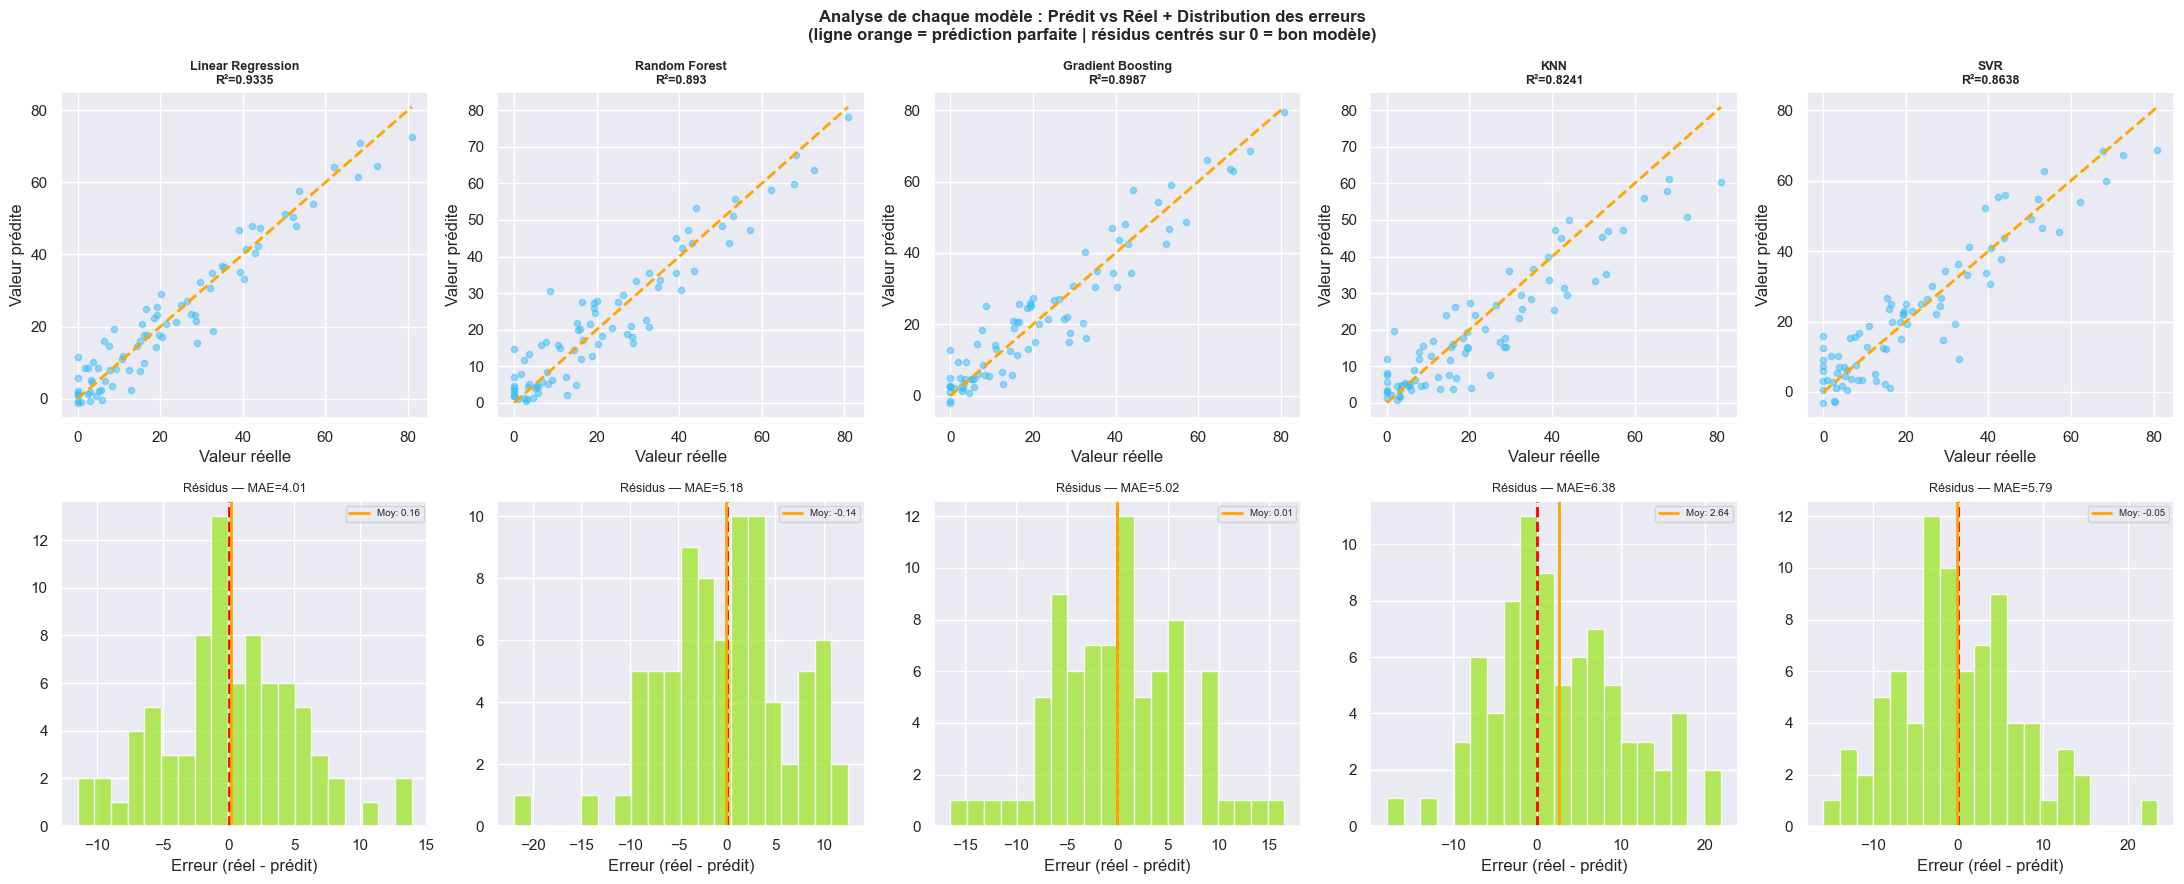

Interprétation :
  → Prédit vs Réel : plus les points sont proches de la diagonale orange, meilleur est le modèle
  → Résidus centrés sur 0 = le modèle ne sur-estime ni ne sous-estime systématiquement


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for col_idx, (name, data) in enumerate(results.items()):
    y_pred = data["y_pred"]
    residus = data["résidus"]

    # Ligne 1 : Prédit vs Réel
    axes[0, col_idx].scatter(y_test, y_pred, alpha=0.5, color="#38bdf8", s=20)
    axes[0, col_idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                           color="orange", linewidth=2, linestyle="--")
    axes[0, col_idx].set_title(f"{name}\nR²={data['R²']}", fontsize=9, fontweight="bold")
    axes[0, col_idx].set_xlabel("Valeur réelle")
    axes[0, col_idx].set_ylabel("Valeur prédite")

    # Ligne 2 : Distribution des résidus
    axes[1, col_idx].hist(residus, bins=20, color="#a3e635", edgecolor="white", alpha=0.8)
    axes[1, col_idx].axvline(0, color="red", linewidth=2, linestyle="--")
    axes[1, col_idx].axvline(residus.mean(), color="orange", linewidth=2,
                              label=f"Moy: {residus.mean():.2f}")
    axes[1, col_idx].set_title(f"Résidus — MAE={data['MAE']}", fontsize=9)
    axes[1, col_idx].set_xlabel("Erreur (réel - prédit)")
    axes[1, col_idx].legend(fontsize=7)

plt.suptitle("Analyse de chaque modèle : Prédit vs Réel + Distribution des erreurs\n"
             "(ligne orange = prédiction parfaite | résidus centrés sur 0 = bon modèle)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Interprétation :")
print("  → Prédit vs Réel : plus les points sont proches de la diagonale orange, meilleur est le modèle")
print("  → Résidus centrés sur 0 = le modèle ne sur-estime ni ne sous-estime systématiquement")

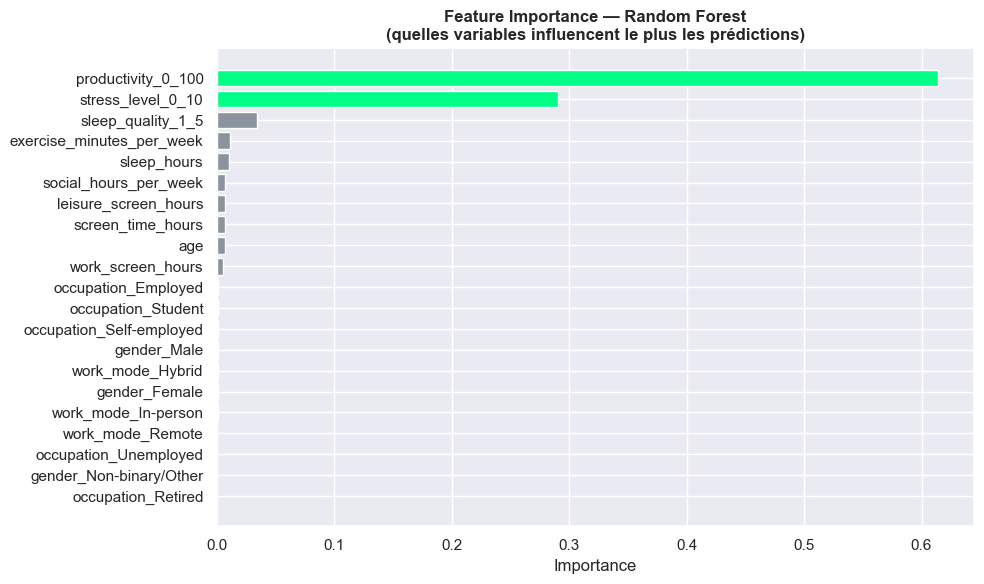

Top 5 features les plus importantes :
productivity_0_100           0.6140
stress_level_0_10            0.2905
sleep_quality_1_5            0.0345
exercise_minutes_per_week    0.0113
sleep_hours                  0.0102


In [12]:
NUMERICAL_COLS = ["age", "screen_time_hours", "work_screen_hours", "leisure_screen_hours",
                  "sleep_hours", "sleep_quality_1_5", "stress_level_0_10",
                  "productivity_0_100", "exercise_minutes_per_week", "social_hours_per_week"]

rf = joblib.load(MODELS_DIR / "random_forest.joblib")
feat_names = (NUMERICAL_COLS +
              list(rf.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out()))
importances = rf.named_steps["regressor"].feature_importances_
fi = pd.Series(importances, index=feat_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#00ff87" if v > 0.15 else "#38bdf8" if v > 0.05 else "#8b949e" for v in fi.values]
ax.barh(fi.index, fi.values, color=colors)
ax.set_title("Feature Importance — Random Forest\n(quelles variables influencent le plus les prédictions)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 features les plus importantes :")
print(fi.sort_values(ascending=False).head(5).round(4).to_string())

In [13]:
df

,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,26,Female,Student,Remote,6.43,2.99,3.44,7.75,1,5.9,64.6,252,7.6,39.3
396,16,Male,Self-employed,Remote,9.59,5.44,4.15,5.57,1,10.0,47.4,99,7.0,3.5
397,40,Male,Student,Remote,8.72,2.36,6.36,7.56,1,9.4,57.3,193,10.1,6.6
398,29,Female,Retired,Hybrid,5.04,0.94,4.10,7.32,1,7.1,63.6,97,12.1,21.0


In [14]:
df.columns

Index(['age', 'gender', 'occupation', 'work_mode', 'screen_time_hours',
       'work_screen_hours', 'leisure_screen_hours', 'sleep_hours',
       'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100',
       'exercise_minutes_per_week', 'social_hours_per_week',
       'mental_wellness_index_0_100'],
      dtype='object')

In [1]:
import seaborn as sns 


sns.heatmap(corr())

NameError: name 'corr' is not defined

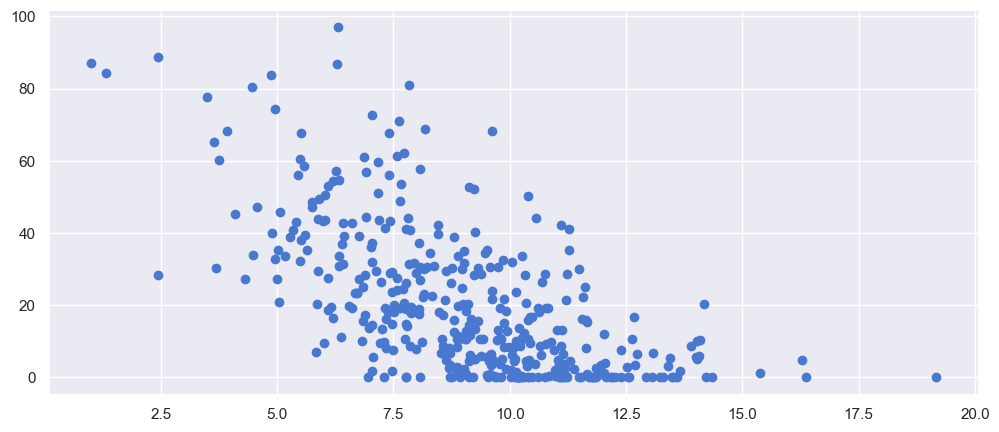

In [17]:
y = df["mental_wellness_index_0_100"]
x = df["screen_time_hours"]

plt.scatter(x, y)